# **Drawing Advanced Shapes and Image Annotation with OpenCV**

---
## Notebook Roadmap

- Learning Objectives
- Prerequisites
- Introduction
- Drawing Polygons
- Filling Shapes
- Adding Text
- Line Types
- Practical Annotation Example
- Common Mistakes
- Best Practices
- Experiments
- Exercises
- Mini Project
- Summary
- Further Reading

---

## **Learning Objectives**

By the end of this notebook, you will be able to:

- Explain what polygons are and how they differ from basic geometric shapes.
- Draw custom polygons using `cv2.polylines()`.
- Fill closed shapes with solid colors using `cv2.fillPoly()`.
- Add text to images with `cv2.putText()` and customize its appearance using different fonts, sizes, colors, and thicknesses.
- Understand the purpose of different OpenCV line types and recognize when to use each one.
- Combine multiple drawing functions to create clear and informative image annotations.
- Build simple graphics and annotation layouts using OpenCV's drawing tools.
- Apply these techniques to real-world computer vision tasks such as object detection, image labeling, and visualization.

---

## Prerequisites

To get the most out of this notebook, you should be familiar with:

- Basic Python programming
- NumPy fundamentals
- Basic image processing concepts
- Working with images in OpenCV
- Drawing basic shapes in OpenCV

If you're following this notebook series in order, you already have all the required background.

---

## **Introduction**

Drawing is one of the most useful features of OpenCV. Beyond creating simple graphics, drawing functions are widely used to **visualize**, **annotate**, and **highlight** information in images. They help transform raw image data into clear, meaningful visual representations.

In this notebook, you'll learn how to draw custom polygons, fill shapes with solid colors, add text to images, and create professional-looking annotations. These techniques are fundamental to many computer vision applications, including object detection, image segmentation, tracking, and image analysis.

By combining the drawing functions introduced in this notebook with the basic shapes from the previous lesson, you'll have a complete toolkit for creating informative and visually appealing image annotations.

---

# **Drawing Polygons**

A **polygon** is a two-dimensional shape formed by connecting a sequence of straight line segments. Unlike circles or rectangles, polygons can have any number of sides, making them ideal for representing custom and irregular shapes.

Because their shape is defined entirely by a set of points, polygons offer much greater flexibility than the basic drawing primitives introduced in the previous notebook.

---

## **1. Components of a Polygon**

A polygon is made up of three main components:

- **Vertices:** The corner points that define the shape.
- **Edges:** The straight line segments connecting consecutive vertices.
- **Interior:** The enclosed region formed when the polygon is closed.

The number and position of the vertices completely determine the final shape of the polygon.

---
## **2. Common Polygon Shapes**

Polygons can have any number of sides. Some common examples include:

- Triangle (3 vertices)
- Quadrilateral (4 vertices)
- Pentagon (5 vertices)
- Hexagon (6 vertices)

By adding or repositioning vertices, you can create virtually any custom shape.

---
## **3. Why Learn to Draw Polygons?**

Polygons are widely used in computer vision because many real-world objects cannot be accurately represented by simple geometric shapes.

They are commonly used for:

- Annotating irregular objects
- Defining regions of interest (ROIs)
- Image segmentation
- Object labeling
- Creating custom graphics and overlays

Learning to draw polygons allows you to visualize and annotate complex shapes with precision.

---

## **4. Drawing Polygons in OpenCV**

OpenCV provides the `cv2.polylines()` function for drawing one or more polygons on an image.

Unlike functions such as `cv2.circle()` or `cv2.rectangle()`, which require only a few parameters, `cv2.polylines()` defines a shape using a collection of vertices. OpenCV then connects these vertices with straight line segments to create the final polygon

### **Syntax**

```python
cv2.polylines(
    img,
    pts,
    isClosed,
    color,
    thickness=1,
    lineType=cv2.LINE_8,
    shift=0
)
```
---

### **Parameters**

| Parameter | Description |
|----------|-------------|
| **`img`** | The image or canvas on which the polygon will be drawn. The function modifies this image directly. |
| **`pts`** | A list of NumPy arrays containing the vertices of one or more polygons. Each polygon is represented by an array of `(x, y)` coordinates. |
| **`isClosed`** | A boolean value (`True` or `False`) that determines whether the last vertex should be connected back to the first. Set it to `True` for a closed polygon or `False` for an open polyline. |
| **`color`** | The color of the polygon outline, specified as a BGR tuple `(Blue, Green, Red)`. Each channel ranges from `0` to `255`. |
| **`thickness`** | The width of the polygon outline in pixels. Larger values produce thicker edges. The default value is `1`. |
| **`lineType`** | Specifies how the edges are drawn. Common options include `cv2.LINE_4`, `cv2.LINE_8` (default), and `cv2.LINE_AA` for smooth, anti-aliased edges. |
| **`shift`** | The number of fractional bits used in the vertex coordinates. A value of `0` means the coordinates are interpreted as integers. This parameter is mainly used for sub-pixel precision and is rarely needed in everyday applications. |

---

### **Return Value**

`cv2.polylines()` draws directly on the input image and returns a reference to the same modified image. It does not create a new image.

> **Note:** In most cases, you can simply call `cv2.polylines()` without assigning its return value to another variable.

---

## **Understanding the `pts` Parameter**

Unlike functions such as `cv2.line()` or `cv2.circle()`, which require only a few coordinates, `cv2.polylines()` needs to know the location of **every vertex** that makes up the polygon.

These vertices are passed through the **`pts`** parameter.

Each vertex is represented as an `(x, y)` coordinate, and together they define the outline of the polygon. OpenCV connects each vertex to the next in the order they are provided.

For example, the following coordinates define a polygon with five vertices:

```python
points = [
    (100, 100),
    (250, 80),
    (350, 180),
    (300, 350),
    (120, 300)
]
```

The vertices are connected in this order:

```
Vertex 1 → Vertex 2 → Vertex 3 → Vertex 4 → Vertex 5
```

If `isClosed=True`, OpenCV automatically connects the **last vertex back to the first**, completing the polygon.

Because OpenCV performs numerical operations on these coordinates, the vertices must be stored as a **NumPy array** rather than a standard Python list.

---

> **We should reshape the vertices**
>
> OpenCV expects the vertices of a polygon to be stored in a specific format with the shape **`(number_of_vertices, 1, 2)`**. However, when we create the vertices as a NumPy array, they are typically stored in the shape **`(number_of_vertices, 2)`**.
>
> Calling
>
> ```python
> points = points.reshape((-1, 1, 2))
> ```
>
> reorganizes the array into the format expected by `cv2.polylines()` without changing the actual coordinate values.
>
> In this expression:
>
> - **`-1`** tells NumPy to automatically determine the number of vertices.
> - **`1`** adds the extra dimension required by OpenCV.
> - **`2`** represents the two coordinates of each vertex: `(x, y)`.
>
> **Remember:** `reshape()` only changes the **structure** of the array, not the data it contains.

In [1]:
import numpy as np

points = np.array([
    [100, 100],
    [250, 80],
    [350, 180],
    [300, 350],
    [120, 300]
], dtype=np.int32)

print("Original shape:", points.shape)
print(points)

points = points.reshape((-1, 1, 2))

print("\nAfter reshape:", points.shape)
print(points)

Original shape: (5, 2)
[[100 100]
 [250  80]
 [350 180]
 [300 350]
 [120 300]]

After reshape: (5, 1, 2)
[[[100 100]]

 [[250  80]]

 [[350 180]]

 [[300 350]]

 [[120 300]]]


## **Drawing a Polygon**

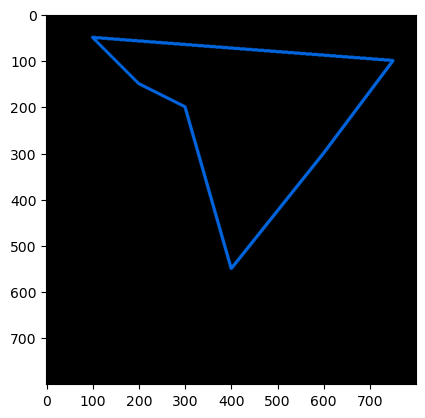

In [2]:
import cv2
import matplotlib.pyplot as plt

canvas = np.zeros((800, 800, 3), dtype=np.uint8)
pts = np.array([
    [100, 50],
    [200, 150],
    [300, 200],
    [400, 550],
    [600, 300],
    [750, 100]
]).reshape((-1, 1, 2))

cv2.polylines(canvas, pts=[pts], isClosed=True, color=(220, 100, 0), thickness=5)

plt.imshow(canvas[..., ::-1])
plt.show()

## **Drawing Multiple Polygons**

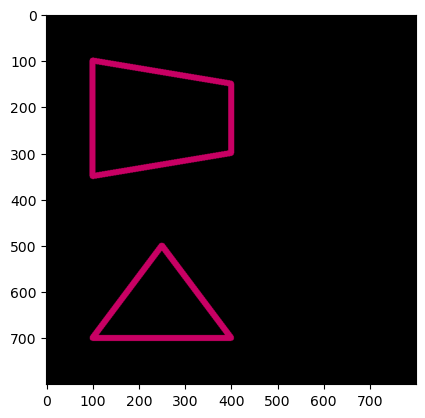

In [3]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)

triangel = np.array([
    [100, 700],
    [250, 500],
    [400, 700]
]).reshape((-1, 1, 2))

quadrilateral = np.array([
    [100, 100],
    [400, 150],
    [400, 300],
    [100, 350]
]).reshape((-1, 1, 2))


cv2.polylines(canvas, pts=[triangel, quadrilateral], isClosed=True, color=(100, 0, 200), thickness=12)

plt.imshow(canvas[..., ::-1])
plt.show()

> **Did You Know?**
>
> When you pass multiple polygons to `cv2.polylines()`, they all share the same drawing properties, including the color, thickness, line type, and whether they are open or closed.
>
> If you want each polygon to have a different appearance, simply call `cv2.polylines()` once for each polygon using the desired drawing parameters.

> **Tips**
>
> - Store vertices in clockwise or counterclockwise order.
> - Use `np.int32` for vertex coordinates.
> - Remember that OpenCV uses `(x, y)` coordinates.
> - Use `cv2.LINE_AA` for smoother edges when visual quality matters.

## **Experiment**

Try modifying the example above:

- Add another vertex.
- Change the order of the vertices.
- Draw the polygon without closing it.
- Increase the line thickness.
- Use different colors and line types.

Observe how each change affects the final shape.

----

# **Filling Shapes**

In many applications, drawing only the outline of a shape is not enough. Instead, we may want to color the entire region enclosed by the shape. This process is known as **shape filling**.

OpenCV provides the `cv2.fillPoly()` function, which fills one or more closed polygons with a specified color. Rather than drawing only the edges, it colors every pixel inside the polygon, creating a solid shape.

Filled polygons are commonly used in computer vision to highlight regions of interest, create masks, visualize segmentation results, and build custom graphics or user interfaces.

---

### **Syntax**

```python
cv2.fillPoly(
    img,
    pts,
    color,
    lineType=cv2.LINE_8,
    shift=0,
    offset=None
)
```
---

### **Parameters**

| Parameter | Description |
|----------|-------------|
| **`img`** | The image or canvas on which the polygons will be filled. |
| **`pts`** | A list of NumPy arrays containing the vertices of one or more polygons. Each polygon must have the shape `(number_of_vertices, 1, 2)`. |
| **`color`** | The fill color, specified as a BGR tuple `(Blue, Green, Red)`. |
| **`lineType`** | Specifies how the polygon boundary is rendered. The default is `cv2.LINE_8`. |
| **`shift`** | The number of fractional bits in the vertex coordinates. The default value is `0`, which means integer coordinates are used. |
| **`offset`** | An optional offset added to every vertex before drawing. This is useful when translating polygons without modifying the original coordinates. |

---

### **Return Value**

Like most OpenCV drawing functions, `cv2.fillPoly()` modifies the input image directly and returns a reference to the same image.

---

### **When Should You Use `cv2.fillPoly()`?**

Although `cv2.polylines()` and `cv2.fillPoly()` both work with polygons, they serve different purposes.

Use **`cv2.polylines()`** when you want to draw only the polygon's outline.

Use **`cv2.fillPoly()`** when you want to color the entire interior of the polygon.

A common workflow is to first fill a polygon and then draw its outline to make the edges more visible.

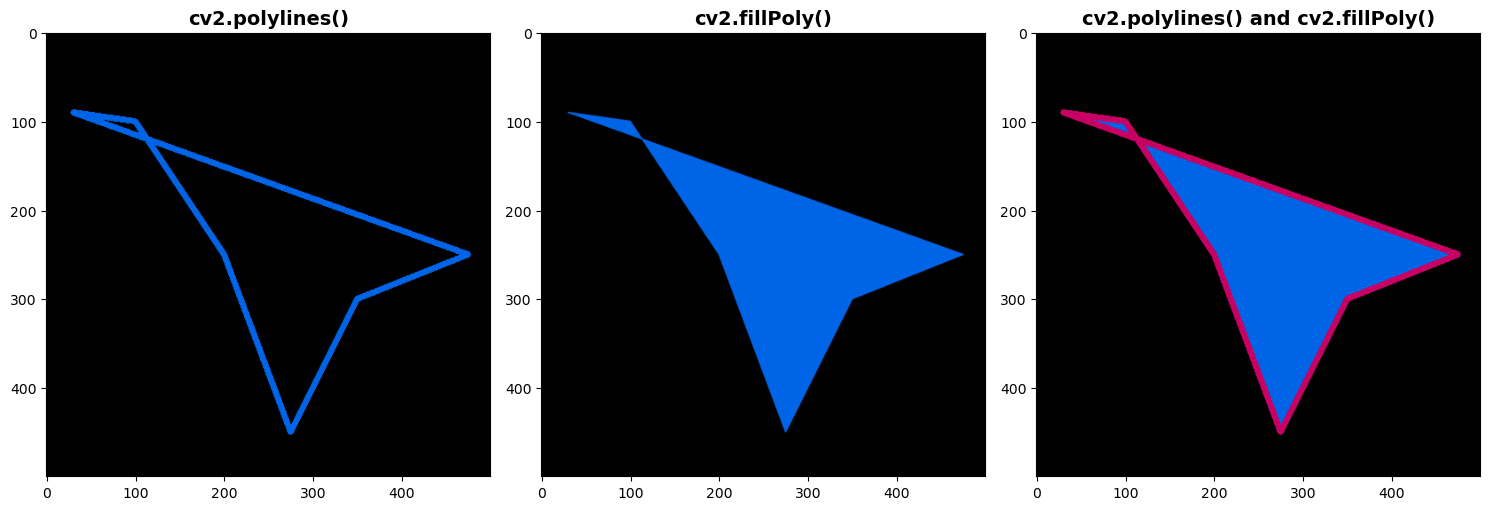

In [11]:
#Initializing vertices
pts = np.array([
    [475, 250],
    [350, 300],
    [275, 450],
    [200, 250],
    [100, 100],
    [30, 90]
]).reshape((-1, 1, 2))

#Creating a polygon using cv2.polylines()
canvas1 = np.zeros((500, 500, 3), dtype=np.uint8)
cv2.polylines(canvas1, [pts], True, (230, 100, 0), 5)

#Creating a filled polygon using cv2.fillPoly()
canvas2 = np.zeros((500, 500, 3), dtype=np.uint8)
cv2.fillPoly(canvas2, [pts], (230, 100, 0), cv2.LINE_AA)

#Creating a polygon using cv2.fillPoly() and cv2.polylines()
canvas3 = np.zeros((500, 500, 3), dtype=np.uint8)
cv2.fillPoly(canvas3, [pts], (230, 100, 0), cv2.LINE_AA)
cv2.polylines(canvas3, [pts], True, (100, 0, 200), 5)

canvases = [canvas1, canvas2, canvas3]
titles = ["cv2.polylines()", "cv2.fillPoly()", "cv2.polylines() and cv2.fillPoly()"]

plt.figure(figsize=(15, 5))

for i in range(3):
    plt.subplot(131 + i); plt.imshow(canvases[i][..., ::-1]); plt.title(titles[i], fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()   

> **Tip**
>
> If you want a polygon with both a colored interior and a clearly visible border, first fill the polygon using `cv2.fillPoly()`, then draw its outline with `cv2.polylines()`. This allows you to customize the outline's color, thickness, and line type independently of the fill color.

# **Adding Text**

Drawing shapes helps us highlight objects and regions in an image, but shapes alone often don't provide enough information. In many applications, we also need to display labels, measurements, scores, timestamps, or other descriptive information.

OpenCV provides the `cv2.putText()` function, which allows you to write text directly onto an image. This makes it an essential tool for image annotation and visualization.

Adding text is widely used in computer vision applications such as object detection, image classification, tracking, medical imaging, and augmented reality.

---

### **Syntax**

```python
cv2.putText(
    img,
    text,
    org,
    fontFace,
    fontScale,
    color,
    thickness=1,
    lineType=cv2.LINE_8,
    bottomLeftOrigin=False
)
```
---

### **Parameters**

| Parameter | Description |
|----------|-------------|
| **`img`** | The image or canvas on which the text will be drawn. |
| **`text`** | The string to display. |
| **`org`** | The position of the **bottom-left corner** of the first character, given as `(x, y)`. |
| **`fontFace`** | The font style used to render the text. |
| **`fontScale`** | A scaling factor that controls the text size. |
| **`color`** | The text color, specified as a BGR tuple. |
| **`thickness`** | The thickness of the characters in pixels. |
| **`lineType`** | Specifies how the text edges are rendered. `cv2.LINE_AA` is recommended for smoother text. |
| **`bottomLeftOrigin`** | If `False` (default), the origin is the top-left corner of the image. If `True`, the origin is the bottom-left corner. |

---

## Understanding the `org` Parameter

Unlike other OpenCV drawing functions, the `org` parameter does **not** specify the top-left corner of the text.

Instead, it defines the **bottom-left corner of the first character**, also known as the **text baseline**.

For example,

```python
org = (100, 200)
```

means that the first character will begin at the coordinate `(100, 200)`, with the rest of the text extending to the right. Most of the characters will be drawn **above** this point.

This behavior is important to remember when positioning text, as assuming `(x, y)` refers to the top-left corner often results in text appearing lower than expected.

---

### **Return Value**

Like other OpenCV drawing functions, `cv2.putText()` modifies the input image directly and returns a reference to the same image.

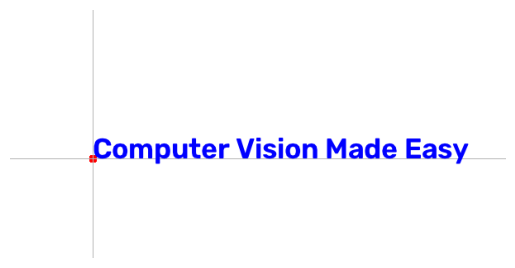

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

canvas = np.ones((300, 600, 3), dtype=np.uint8) * 255

origin = (100, 180)

# Mark the origin
cv2.circle(canvas, origin, 5, (0, 0, 255), -1)

# Guide lines
cv2.line(canvas, (0, origin[1]), (600, origin[1]), (180, 180, 180), 1)
cv2.line(canvas, (origin[0], 0), (origin[0], 300), (180, 180, 180), 1)

# Draw the text
cv2.putText(
    canvas,
    "Computer Vision Made Easy",
    origin,
    cv2.FONT_HERSHEY_SIMPLEX,
    1.2,
    (255, 0, 0),
    2,
    cv2.LINE_AA
)

plt.imshow(canvas[..., ::-1])
plt.axis("off")
plt.show()

> **Note**
>
> The `org` parameter specifies the position of the **first character**, not the entire text. As the text becomes longer, it extends horizontally to the right from this point.

# **Line Types**

When drawing shapes or text, OpenCV lets you choose how the edges are rendered through the `lineType` parameter.

Different line types affect the appearance of edges, especially diagonal and curved lines. Choosing the appropriate line type can improve the readability and visual quality of your drawings.

---
## **Available Line Types**

OpenCV provides three commonly used line types:

| Line Type | Description |
|-----------|-------------|
| `cv2.LINE_4` | Uses 4-connected pixels. Produces simple edges with a blocky appearance. |
| `cv2.LINE_8` | Uses 8-connected pixels. This is the default option and produces smoother lines than `LINE_4`. |
| `cv2.LINE_AA` | Uses anti-aliasing to smooth the edges, reducing the jagged appearance of diagonal and curved lines. Best suited for visualization and text. |

---

## **What Is Anti-Aliasing?**

Digital images are made of square pixels. When drawing diagonal or curved lines, these pixels can create a jagged or "stair-step" appearance, an effect known as **aliasing**.

**Anti-aliasing** reduces this effect by smoothing the edges with intermediate pixel intensities, producing cleaner and more natural-looking lines.

In OpenCV, anti-aliased lines are created using `cv2.LINE_AA`.

---
 > **Best Practices**
>
> - Use `cv2.LINE_AA` for text, curved shapes, and visualizations where appearance matters.
> - Use `cv2.LINE_8` for general-purpose drawing.
> - Use `cv2.LINE_4` only when a 4-connected representation is specifically required.

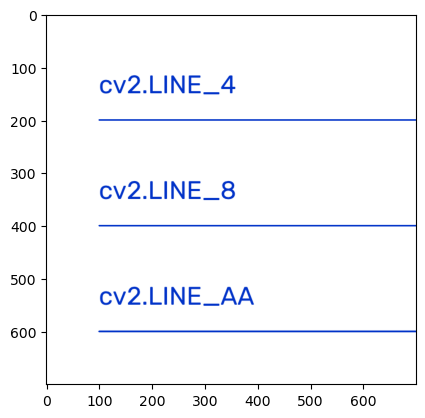

In [47]:
lines = {
    "cv2.LINE_4" : cv2.LINE_4,
    "cv2.LINE_8" : cv2.LINE_8,
    "cv2.LINE_AA" : cv2.LINE_AA}
y = 200
canvas = np.ones((700, 700, 3), dtype=np.uint8) * 255

for title, line in lines.items():
    cv2.line(canvas, (100, y), (800, y), (200, 50, 0), 2, line)
    cv2.putText(canvas, title, (100, y - 50), cv2.FONT_HERSHEY_PLAIN, 3, (200, 50, 0), 1, line)
    y += 200
    
plt.imshow(canvas[..., ::-1])
plt.show()  

# **Building an Image Annotation**

In real-world computer vision applications, drawing functions are rarely used in isolation. Instead, they are combined to visualize model predictions, highlight objects, and display useful information directly on an image.

A typical annotation may include:

- A polygon outlining an object or region of interest.
- A filled polygon to emphasize the selected area.
- A label identifying the object.
- Additional information such as a confidence score or measurement.

In this example, we'll combine several OpenCV drawing functions to create a simple image annotation similar to those produced by object detection and segmentation models.

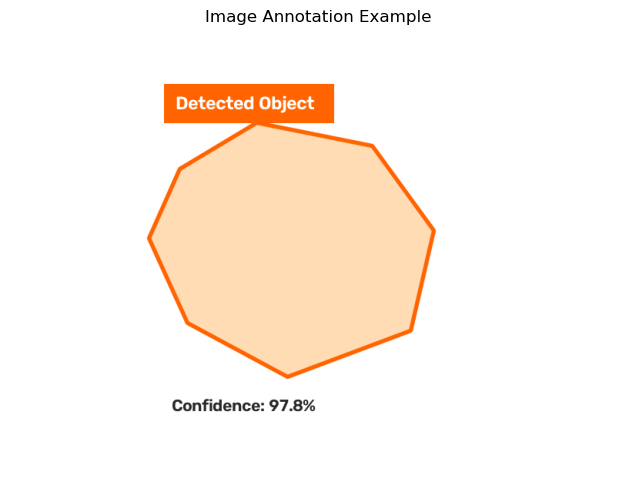

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Create a blank white canvas
canvas = np.ones((600, 800, 3), dtype=np.uint8) * 255

# Define the polygon vertices
polygon = np.array([
    [220, 180],
    [320, 120],
    [470, 150],
    [550, 260],
    [520, 390],
    [360, 450],
    [230, 380],
    [180, 270]
], dtype=np.int32).reshape((-1, 1, 2))

# Fill the polygon
cv2.fillPoly(
    canvas,
    [polygon],
    color=(180, 220, 255)
)

# Draw the polygon outline
cv2.polylines(
    canvas,
    [polygon],
    isClosed=True,
    color=(0, 100, 255),
    thickness=3,
    lineType=cv2.LINE_AA
)

# Draw a label background
cv2.rectangle(
    canvas,
    (200, 70),
    (420, 120),
    (0, 100, 255),
    -1
)

# Add the object label
cv2.putText(
    canvas,
    "Detected Object",
    (215, 103),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (255, 255, 255),
    2,
    cv2.LINE_AA
)

# Add a confidence score
cv2.putText(
    canvas,
    "Confidence: 97.8%",
    (210, 495),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.75,
    (40, 40, 40),
    2,
    cv2.LINE_AA
)

# Display the result
plt.figure(figsize=(8, 6))
plt.imshow(canvas[..., ::-1])
plt.title("Image Annotation Example")
plt.axis("off")
plt.show()

## **Understanding the Annotation**

This example combines multiple OpenCV drawing functions to create a complete annotation.

- `cv2.fillPoly()` highlights the detected region.
- `cv2.polylines()` draws a clear boundary around the object.
- `cv2.putText()` displays the object's label and confidence score.
- `cv2.LINE_AA` smooths the text and outline, improving readability.

This workflow is commonly used in object detection, image segmentation, medical imaging, and many other computer vision applications.

---

# **Common Mistakes**

When working with OpenCV's drawing functions, beginners often encounter a few common issues. Being aware of these mistakes can save time and make debugging much easier.

### 1. Forgetting to Reshape Polygon Vertices

`cv2.polylines()` and `cv2.fillPoly()` expect polygon vertices to have the shape `(number_of_vertices, 1, 2)`. Passing an array with the wrong shape may produce unexpected results or errors.

---

### 2. Using Floating-Point Coordinates

Drawing functions expect integer pixel coordinates. If your coordinates are floating-point values, convert them to `np.int32` before drawing.

---

### 3. Mixing Up RGB and BGR

OpenCV stores colors in **BGR** order, while Matplotlib expects **RGB**. When displaying images with Matplotlib, remember to convert the color channels:

```python
plt.imshow(image[..., ::-1])
```

---

### 4. Assuming Drawing Functions Create a New Image

Functions such as `cv2.polylines()`, `cv2.fillPoly()`, and `cv2.putText()` modify the original image directly. Create a copy first if you want to preserve the original.

---

### 5. Confusing the `org` Parameter

In `cv2.putText()`, the `org` parameter specifies the **bottom-left corner of the first character**, not the top-left corner of the text.

---

# **Best Practices**

Following a few simple practices can make your OpenCV drawing code more readable, reusable, and easier to maintain.

- **Store vertices in a NumPy array.** OpenCV drawing functions expect polygon coordinates as NumPy arrays with an appropriate data type.

- **Use meaningful variable names.** Names such as `triangle`, `contour`, or `vertices` are more descriptive than generic names like `pts` or `arr`.

- **Use `cv2.LINE_AA` for smoother visualizations.** Anti-aliased lines and text generally produce cleaner, more professional-looking results.

- **Keep drawing parameters consistent.** Reusing the same colors, line thicknesses, and fonts helps create clear and visually consistent annotations.

- **Create a copy before drawing.** If you need to preserve the original image, use `image.copy()` before applying any drawing functions.

- **Organize drawing code logically.** When creating annotations, it's often helpful to draw in this order:
  1. Filled shapes
  2. Shape outlines
  3. Text and labels

  This ensures that important details remain visible.

---

# **Experiments**

Try modifying the examples in this notebook and observe how the output changes.

- Draw the same polygon using different numbers of vertices.
- Compare an open polygon with a closed polygon.
- Change the fill and outline colors of a polygon.
- Experiment with different line types (`LINE_4`, `LINE_8`, and `LINE_AA`).
- Try different fonts, font scales, and thicknesses when adding text.
- Combine multiple polygons and labels to create your own annotated scene.

Small experiments like these are an excellent way to build confidence and develop an intuition for OpenCV's drawing functions.

---

# **Exercises**

Test your understanding by completing the following exercises. Try solving them on your own before looking up the answers.

### Exercise 1: Draw a Triangle
Create a blank canvas and draw a closed triangle with a blue outline.

---

### Exercise 2: Fill a Polygon
Draw a hexagon and fill it with a color of your choice. Then add a black outline around it.

---

### Exercise 3: Label a Shape
Draw any polygon and place a descriptive label above it using `cv2.putText()`.

---

### Exercise 4: Compare Line Types
Draw the same diagonal line three times using `cv2.LINE_4`, `cv2.LINE_8`, and `cv2.LINE_AA`. Observe the differences in their appearance.

---

### Exercise 5: Create a Simple Annotation
Design a simple annotation by combining:
- A filled polygon
- A polygon outline
- A text label
- A confidence score

Try arranging these elements so that the annotation is clear and visually appealing.

---

# **Mini Project**

## **Build Your Own Image Annotation**

Create a small annotated scene from scratch using the drawing functions you've learned in this notebook.

Your scene should include:

- At least **two polygons**
- One or more **filled shapes**
- A clear **text label** for each object
- At least **two different colors**
- Smooth outlines using `cv2.LINE_AA`

Feel free to be creative! You could draw a simple map, a park, a building layout, a traffic sign, or an imaginary scene. The goal is to practice combining multiple OpenCV drawing functions into a single, well-organized visualization.

---

# **Summary**

Congratulations! In this notebook, you explored OpenCV's advanced drawing functions and learned how to create informative image annotations.

Here's a quick recap of what you learned:

- How to draw custom polygons using `cv2.polylines()`.
- How to fill polygons with solid colors using `cv2.fillPoly()`.
- How to add text to images using `cv2.putText()`.
- How different line types affect the appearance of shapes and text.
- How to combine multiple drawing functions to build clear and professional image annotations.

These drawing techniques are fundamental tools in computer vision and are widely used for visualization, object detection, image segmentation, tracking, and many other real-world applications.

With these skills, you're now able to create your own graphics, highlight regions of interest, and annotate images effectively using OpenCV.

---
# **Further Reading**

If you'd like to explore OpenCV's drawing capabilities in more depth, check out the following resources:

- **OpenCV Documentation:** https://docs.opencv.org/
- **OpenCV-Python Tutorials:** https://docs.opencv.org/master/d6/d00/tutorial_py_root.html
- **NumPy Documentation:** https://numpy.org/doc/